# Urgency Tagging with GRU Model

In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')
    
    PROJECT_ROOT = '/content/drive/MyDrive/lentera-analytics-hub/lentera-ml-research'
    if not os.path.exists(PROJECT_ROOT):
        PROJECT_ROOT = '/content/drive/MyDrive/lentera-ml-research'
        
    os.chdir(PROJECT_ROOT)
    print(f"Berjalan di Google Colab. Direktori aktif saat ini: {os.getcwd()}")
else:
    notebook_dir = os.getcwd()
    if os.path.basename(notebook_dir) == 'notebooks':
        PROJECT_ROOT = os.path.abspath(os.path.join(notebook_dir, '..'))
    else:
        PROJECT_ROOT = notebook_dir
    os.chdir(PROJECT_ROOT)
    print(f"Berjalan secara lokal. Project root: {PROJECT_ROOT}")

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)


from src.features import split_data, extract_lstm_sequences

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, GRU, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.regularizers import l2

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight

sns.set_theme(style='whitegrid')
print("Semua library berhasil diimport.")

Berjalan secara lokal. Project root: d:\Projek\lentera-analytics-hub\lentera-ml-research
Semua library berhasil diimport.


## 1. Load dan Validasi Dataset Bersih

In [2]:
DATA_PATH = os.path.join(PROJECT_ROOT, 'data', 'processed', 'cleaned_complaints.csv')

df = pd.read_csv(DATA_PATH)
print(f"Dataset berhasil dimuat. Shape awal: {df.shape}")
print(f"Kolom tersedia: {df.columns.tolist()}")
print()

df = df.dropna(subset=['Cleaned_Narrative', 'Urgency'])
print(f"Shape setelah dropna: {df.shape}")
print()

print("Distribusi kelas Urgency:")
print(df['Urgency'].value_counts())

Dataset berhasil dimuat. Shape awal: (121485, 3)
Kolom tersedia: ['Raw_Filtered_Narrative', 'Cleaned_Narrative', 'Urgency']

Shape setelah dropna: (121485, 3)

Distribusi kelas Urgency:
Urgency
High      52471
Medium    49583
Low       19431
Name: count, dtype: int64


## 2. Pembagian Data (Data Splitting)
Kita membagi dataset secara stratified menjadi Train (70%), Validation (15%), dan Test (15%) dengan menggunakan fungsi `split_data` yang sudah tersedia di `src.features`.

In [3]:
df_train, df_val, df_test = split_data(
    df,
    text_col='Cleaned_Narrative',
    target_col='Urgency'
)

Train size: 85039, Val size: 18223, Test size: 18223


## 3. Label Encoding Target
Model deep learning membutuhkan target numerik. Kita akan mengodekan target kategori `'High'`, `'Low'`, dan `'Medium'` menggunakan `LabelEncoder` dari scikit-learn.

In [4]:
label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(df_train['Urgency'])
y_val_encoded = label_encoder.transform(df_val['Urgency'])
y_test_encoded = label_encoder.transform(df_test['Urgency'])

class_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print("Pemetaan kelas target:", class_mapping)

Pemetaan kelas target: {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}


## 4. Tokenisasi dan Padding Sekuens

In [5]:
X_train_pad, X_val_pad, X_test_pad, tokenizer = extract_lstm_sequences(
    df_train['Cleaned_Narrative'],
    df_val['Cleaned_Narrative'],
    df_test['Cleaned_Narrative'],
    max_words=10000,
    max_len=150
)

print(f"Shape data sekuens:")
print(f"  X_train_pad : {X_train_pad.shape}")
print(f"  X_val_pad   : {X_val_pad.shape}")
print(f"  X_test_pad  : {X_test_pad.shape}")

Shape data sekuens:
  X_train_pad : (85039, 150)
  X_val_pad   : (18223, 150)
  X_test_pad  : (18223, 150)


## 5. Penanganan Kelas Imbalanced

In [6]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_encoded),
    y=y_train_encoded
)

class_weights_dict = dict(enumerate(class_weights))
print("Bobot kelas:", class_weights_dict)

Bobot kelas: {0: np.float64(0.7717698095056585), 1: np.float64(2.083982747635152), 2: np.float64(0.8167089239752603)}


## 6. Arsitektur Model GRU

In [7]:
vocab_size = 10000
embedding_dim = 64 
max_len = 150
num_classes = len(class_mapping)
model = Sequential([
    Input(shape=(max_len,)),
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, mask_zero=True),
    Bidirectional(GRU(64, dropout=0.4, recurrent_dropout=0.2)),
    Dense(32, activation='relu', kernel_regularizer=l2(0.01)),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 150, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        49,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 694,147 (2.65 MB)

 Trainable params: 694,147 (2.65 MB)

 Non-trainable params: 0 (0.00 B)

## 7. Pelatihan Model (Training)

In [8]:
model_dir = os.path.join(PROJECT_ROOT, 'models')
os.makedirs(model_dir, exist_ok=True)
model_save_path = os.path.join(model_dir, 'gru_urgency_model.keras')

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

model_checkpoint = ModelCheckpoint(
    filepath=model_save_path,
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

epochs = 10
batch_size = 64

history = model.fit(
    X_train_pad,
    y_train_encoded,
    validation_data=(X_val_pad, y_val_encoded),
    epochs=epochs,
    batch_size=batch_size,
    class_weight=class_weights_dict,
    callbacks=[early_stopping, model_checkpoint]
)

Epoch 1/10
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - accuracy: 0.6410 - loss: 0.8689
Epoch 1: val_loss improved from None to 0.47395, saving model to d:\Projek\lentera-analytics-hub\lentera-ml-research\models\gru_urgency_model.keras

Epoch 1: finished saving model to d:\Projek\lentera-analytics-hub\lentera-ml-research\models\gru_urgency_model.keras
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 258s 189ms/step - accuracy: 0.7360 - loss: 0.6676 - val_accuracy: 0.8131 - val_loss: 0.4740
Epoch 2/10
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - accuracy: 0.8100 - loss: 0.5084
Epoch 2: val_loss improved from 0.47395 to 0.46546, saving model to d:\Projek\lentera-analytics-hub\lentera-ml-research\models\gru_urgency_model.keras

Epoch 2: finished saving model to d:\Projek\lentera-analytics-hub\lentera-ml-research\models\gru_urgency_model.keras
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 242s 182ms/step - accuracy: 0.8085 - loss: 0.5097 - val_accuracy: 0.8130 - val_loss: 0.4655
Epoch 3/10
1329/1329 ━━━━━━━━━━━━━━━━━━

## 8. Visualisasi Riwayat Pelatihan

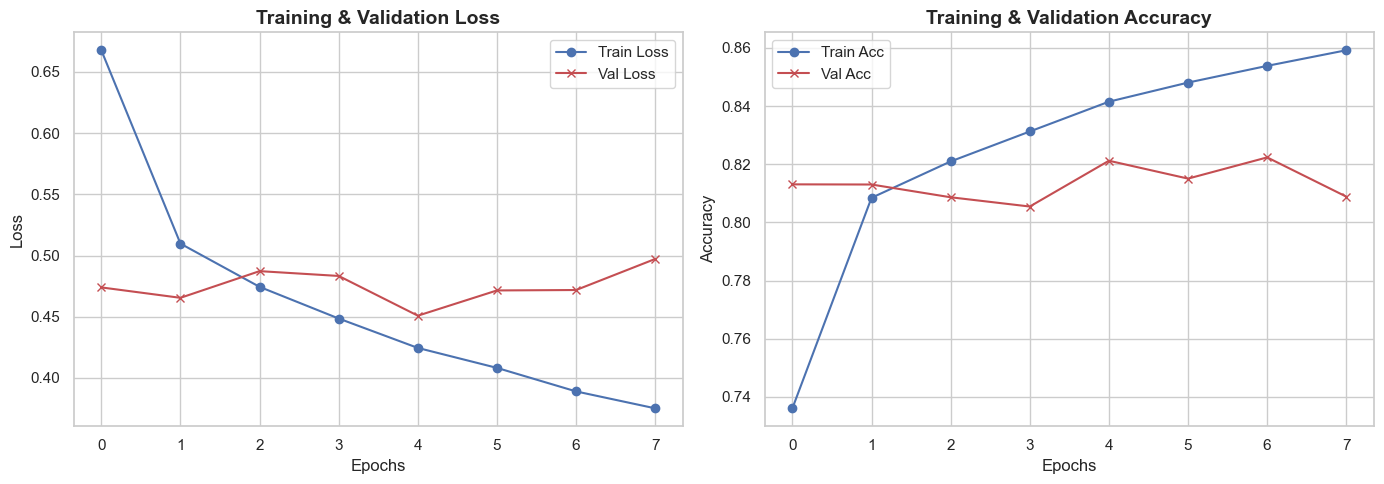

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['loss'], label='Train Loss', color='b', marker='o')
ax1.plot(history.history['val_loss'], label='Val Loss', color='r', marker='x')
ax1.set_title('Training & Validation Loss', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()

ax2.plot(history.history['accuracy'], label='Train Acc', color='b', marker='o')
ax2.plot(history.history['val_accuracy'], label='Val Acc', color='r', marker='x')
ax2.set_title('Training & Validation Accuracy', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.tight_layout()
plt.show()

## 9. Evaluasi Model pada Test Set

570/570 ━━━━━━━━━━━━━━━━━━━━ 12s 20ms/step
  EVALUASI MODEL GRU (Test Set)
              precision    recall  f1-score   support

        High       0.93      0.85      0.89      7871
         Low       0.60      0.79      0.68      2915
      Medium       0.83      0.81      0.82      7437

    accuracy                           0.82     18223
   macro avg       0.79      0.82      0.80     18223
weighted avg       0.84      0.82      0.83     18223



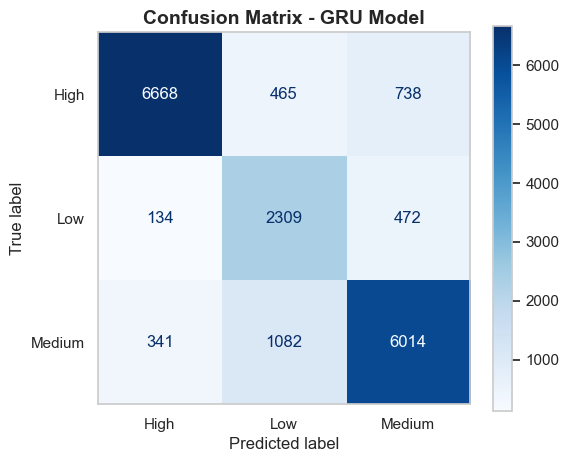

In [10]:
y_pred_probs = model.predict(X_test_pad)
y_pred = np.argmax(y_pred_probs, axis=1)

print("=" * 60)
print("  EVALUASI MODEL GRU (Test Set)")
print("=" * 60)
print(classification_report(
    y_test_encoded,
    y_pred,
    target_names=label_encoder.classes_
))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test_encoded,
    y_pred,
    display_labels=label_encoder.classes_,
    cmap='Blues',
    ax=ax
)
ax.set_title('Confusion Matrix - GRU Model', fontsize=14, fontweight='bold')
plt.grid(False)
plt.show()